In [5]:
import os
import copy
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from torchvision.models import resnet18, resnet50
from torchvision.models import ResNet18_Weights, ResNet50_Weights

from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [7]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

DATASET_PATH = "/content/chest_xray"
train_dir = os.path.join(DATASET_PATH, "train")
val_dir   = os.path.join(DATASET_PATH, "val")
test_dir  = os.path.join(DATASET_PATH, "test")

IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 4
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 2

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=test_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

class_names = train_dataset.classes
print("Classes:", class_names)
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

dataloaders = {
    "train": train_loader,
    "val": val_loader
}

dataset_sizes = {
    "train": len(train_dataset),
    "val": len(val_dataset)
}

def build_model(model_name="resnet18"):
    if model_name == "resnet18":
        model = resnet18(weights=ResNet18_Weights.DEFAULT)
    elif model_name == "resnet50":
        model = resnet50(weights=ResNet50_Weights.DEFAULT)
    else:
        raise ValueError("Choose 'resnet18' or 'resnet50'")

    for param in model.parameters():
        param.requires_grad = False

    for param in model.layer3.parameters():
        param.requires_grad = True
    for param in model.layer4.parameters():
        param.requires_grad = True

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 2)
    )

    for param in model.fc.parameters():
        param.requires_grad = True

    return model.to(device)

def train_model(model, model_name, dataloaders, dataset_sizes, num_epochs=4, patience=2):
    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    best_val_loss = float("inf")
    early_stop_counter = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        print(f"\n{model_name} | Epoch {epoch+1}/{num_epochs}")
        print("-" * 40)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in tqdm(dataloaders[phase], leave=False):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double().item() / dataset_sizes[phase]

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} | {phase.capitalize()} Acc: {epoch_acc:.4f}")

            if phase == "val":
                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

                if epoch_loss < best_val_loss:
                    best_val_loss = epoch_loss
                    early_stop_counter = 0
                else:
                    early_stop_counter += 1

        scheduler.step()

        if early_stop_counter >= patience:
            print(f"Early stopping triggered for {model_name}")
            break

    model.load_state_dict(best_model_wts)
    return model, history

def evaluate_model(model, dataloader, class_names, model_name="Model"):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc=f"Testing {model_name}", leave=False):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    print(f"\n{model_name} Test Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names))
    print(confusion_matrix(y_true, y_pred))
    return acc

model18 = build_model("resnet18")
model50 = build_model("resnet50")

model18, history18 = train_model(model18, "ResNet18", dataloaders, dataset_sizes, num_epochs=EPOCHS, patience=PATIENCE)
model50, history50 = train_model(model50, "ResNet50", dataloaders, dataset_sizes, num_epochs=EPOCHS, patience=PATIENCE)

acc18 = evaluate_model(model18, test_loader, class_names, "ResNet18")
acc50 = evaluate_model(model50, test_loader, class_names, "ResNet50")

print("\nFinal Test Accuracy Comparison")
print(f"ResNet18: {acc18:.4f}")
print(f"ResNet50: {acc50:.4f}")

Device: cuda
Classes: ['NORMAL', 'PNEUMONIA']
Train size: 5216
Val size: 16
Test size: 624

ResNet18 | Epoch 1/4
----------------------------------------


  0%|          | 0/326 [00:00<?, ?it/s]

Train Loss: 0.1340 | Train Acc: 0.9503


  0%|          | 0/1 [00:00<?, ?it/s]

Val Loss: 0.8819 | Val Acc: 0.6250

ResNet18 | Epoch 2/4
----------------------------------------


...

Val Loss: 0.3118 | Val Acc: 0.8125
Early stopping triggered for ResNet50


Testing ResNet18:   0%|          | 0/39 [00:00<?, ?it/s]


ResNet18 Test Accuracy: 0.8734
              precision    recall  f1-score   support

      NORMAL       0.95      0.70      0.81       234
   PNEUMONIA       0.84      0.98      0.91       390

    accuracy                           0.87       624
   macro avg       0.90      0.84      0.86       624
weighted avg       0.88      0.87      0.87       624

[[164  70]
 [  9 381]]


Testing ResNet50:   0%|          | 0/39 [00:00<?, ?it/s]


ResNet50 Test Accuracy: 0.8926
              precision    recall  f1-score   support

      NORMAL       0.96      0.75      0.84       234
   PNEUMONIA       0.87      0.98      0.92       390

    accuracy                           0.89       624
   macro avg       0.91      0.86      0.88       624
weighted avg       0.90      0.89      0.89       624

[[175  59]
 [  8 382]]

Final Test Accuracy Comparison
ResNet18: 0.8734
ResNet50: 0.8926


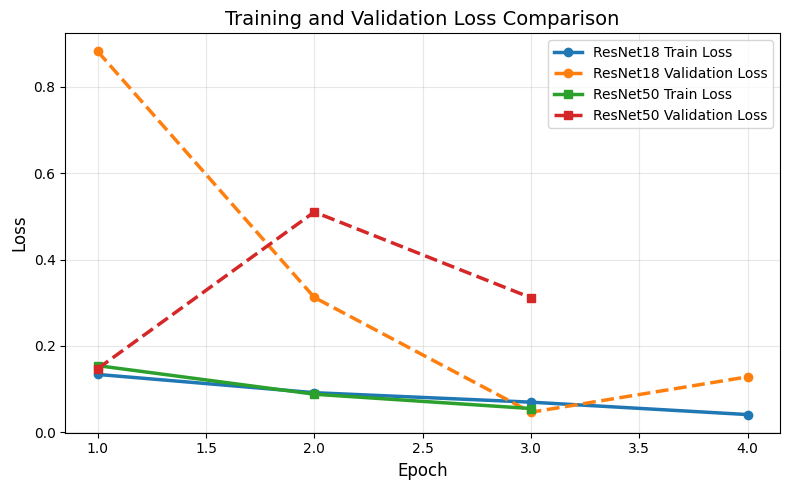

In [8]:
plt.figure(figsize=(8,5))

epochs18 = range(1, len(history18["train_loss"]) + 1)
epochs50 = range(1, len(history50["train_loss"]) + 1)

# ResNet18
plt.plot(
    epochs18,
    history18["train_loss"],
    marker='o',
    linewidth=2.5,
    color="#1f77b4",
    label="ResNet18 Train Loss"
)

plt.plot(
    epochs18,
    history18["val_loss"],
    marker='o',
    linewidth=2.5,
    linestyle="--",
    color="#ff7f0e",
    label="ResNet18 Validation Loss"
)

# ResNet50
plt.plot(
    epochs50,
    history50["train_loss"],
    marker='s',
    linewidth=2.5,
    color="#2ca02c",
    label="ResNet50 Train Loss"
)

plt.plot(
    epochs50,
    history50["val_loss"],
    marker='s',
    linewidth=2.5,
    linestyle="--",
    color="#d62728",
    label="ResNet50 Validation Loss"
)

plt.title("Training and Validation Loss Comparison", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()